# 3. Feature Engineering
We create 8 new features including loan-to-income ratio, credit age,
and binary risk flags to improve model signal.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/cleaned_loan_data.csv')
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method
0,30000,36 months,22.35,1151.16,D,D5,Supervisor,5 years,MORTGAGE,100000.0,...,2.0,89.5,33.3,1.0,0.0,527120.0,98453.0,28600.0,101984.0,Cash
1,40000,60 months,16.14,975.71,C,C4,Assistant to the Treasurer (Payroll),< 1 year,MORTGAGE,45000.0,...,4.0,100.0,42.9,0.0,0.0,344802.0,161720.0,45700.0,167965.0,Cash
2,20000,36 months,7.56,622.68,A,A3,Teacher,10+ years,MORTGAGE,100000.0,...,1.0,94.7,20.0,0.0,0.0,622183.0,71569.0,85100.0,74833.0,Cash
3,4500,36 months,11.31,147.99,B,B3,Accounts Examiner III,10+ years,RENT,38500.0,...,4.0,91.7,0.0,0.0,0.0,53795.0,29137.0,15100.0,24595.0,Cash
4,8425,36 months,27.27,345.18,E,E5,Senior Director Risk Management,3 years,MORTGAGE,450000.0,...,2.0,100.0,50.0,0.0,0.0,768304.0,189194.0,45800.0,189054.0,Cash


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79872 entries, 0 to 79871
Data columns (total 78 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   79872 non-null  int64  
 1   term                        79872 non-null  object 
 2   int_rate                    79872 non-null  float64
 3   installment                 79872 non-null  float64
 4   grade                       79872 non-null  object 
 5   sub_grade                   79872 non-null  object 
 6   emp_title                   79872 non-null  object 
 7   emp_length                  79872 non-null  object 
 8   home_ownership              79872 non-null  object 
 9   annual_inc                  79872 non-null  float64
 10  verification_status         79872 non-null  object 
 11  issue_d                     79872 non-null  object 
 12  loan_status                 79872 non-null  object 
 13  purpose                     798

In [ ]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='mixed', dayfirst=False)
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='mixed', dayfirst=False)

df['credit_age_years'] = (df['issue_d'] - df['earliest_cr_line']).dt.days / 365.25

df['loan_to_income_ratio'] = df['loan_amnt'] / df['annual_inc']
df['monthly_payment_to_income'] =df['installment'] / (df['annual_inc'])/12

df['monthly_payment_to_income']

df['high_utilization_flag']=(df['revol_util']>75).astype(int)
df['has_publi_rec']=(df['pub_rec']>0).astype(int)

df = pd.get_dummies(df, columns=['purpose', 'home_ownership', 'verification_status',
                                  'application_type', 'initial_list_status',
                                  'disbursement_method'], drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79872 entries, 0 to 79871
Data columns (total 97 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   loan_amnt                            79872 non-null  int64         
 1   term                                 79872 non-null  object        
 2   int_rate                             79872 non-null  float64       
 3   installment                          79872 non-null  float64       
 4   grade                                79872 non-null  object        
 5   sub_grade                            79872 non-null  object        
 6   emp_title                            79872 non-null  object        
 7   emp_length                           79872 non-null  object        
 8   annual_inc                           79872 non-null  float64       
 9   issue_d                              79872 non-null  datetime64[ns]
 10  loan_statu

In [ ]:
# correlation_matrix = df.select_dtypes(include=[np.number]).corr()
# display(correlation_matrix.head())

correlation_matrix=df.select_dtypes(include=np.number).corr()
correlation_matrix.head(5)

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_age_years,loan_to_income_ratio,monthly_payment_to_income,high_utilization_flag,has_publi_rec
loan_amnt,1.000000,0.126782,0.953669,0.272711,0.031844,-0.009081,-0.008619,0.152335,-0.034469,0.268958,...,0.015340,0.286486,0.222356,0.320669,0.171366,0.110637,0.001326,0.000605,0.038958,-0.048742
int_rate,0.126782,1.000000,0.170415,-0.064195,0.135749,0.069551,0.142698,0.001728,0.046905,0.024706,...,0.018793,-0.105374,0.051316,-0.220586,0.030702,-0.100554,-0.000685,-0.000495,0.169559,0.049306
installment,0.953669,0.170415,1.000000,0.264229,0.047345,0.004841,0.009670,0.151218,-0.022174,0.269270,...,0.024441,0.255230,0.217429,0.285427,0.164299,0.093418,0.001223,0.001046,0.062503,-0.038030
annual_inc,0.272711,-0.064195,0.264229,1.000000,-0.126314,0.036872,0.031079,0.134700,-0.007083,0.305917,...,0.034434,0.417398,0.311342,0.266496,0.265453,0.129165,-0.006032,-0.006024,0.051736,-0.020764
dti,0.031844,0.135749,0.047345,-0.126314,1.000000,-0.008497,-0.005636,0.172664,-0.014557,0.106196,...,-0.016808,0.047758,0.196791,0.020359,0.221696,0.041506,0.019038,0.018874,0.059803,-0.008599


In [ ]:
high_corr_threshold = 0.8
highly_correlated_pairs = []

# Iterate through the correlation matrix to find highly correlated pairs
for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[1]): # Avoid duplicate pairs and self-correlation
        if abs(correlation_matrix.iloc[i, j]) > high_corr_threshold:
            highly_correlated_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# Display the highly correlated pairs
if highly_correlated_pairs:
    print(f"Features with absolute correlation > {high_corr_threshold}:")
    for feature1, feature2, correlation_value in highly_correlated_pairs:
        print(f"- '{feature1}' and '{feature2}' (Correlation: {correlation_value:.2f})")
else:
    print("No features found with absolute correlation greater than 0.8.")

Features with absolute correlation > 0.8:
- 'loan_amnt' and 'installment' (Correlation: 0.95)
- 'open_acc' and 'num_op_rev_tl' (Correlation: 0.85)
- 'open_acc' and 'num_sats' (Correlation: 1.00)
- 'pub_rec' and 'has_publi_rec' (Correlation: 0.83)
- 'revol_util' and 'bc_util' (Correlation: 0.88)
- 'acc_now_delinq' and 'num_tl_30dpd' (Correlation: 0.82)
- 'tot_cur_bal' and 'avg_cur_bal' (Correlation: 0.82)
- 'tot_cur_bal' and 'tot_hi_cred_lim' (Correlation: 0.98)
- 'total_bal_il' and 'total_bal_ex_mort' (Correlation: 0.91)
- 'total_bal_il' and 'total_il_high_credit_limit' (Correlation: 0.96)
- 'open_rv_12m' and 'num_tl_op_past_12m' (Correlation: 0.83)
- 'open_rv_24m' and 'acc_open_past_24mths' (Correlation: 0.84)
- 'total_rev_hi_lim' and 'total_bc_limit' (Correlation: 0.80)
- 'bc_open_to_buy' and 'total_bc_limit' (Correlation: 0.87)
- 'bc_util' and 'percent_bc_gt_75' (Correlation: 0.85)
- 'mo_sin_old_rev_tl_op' and 'credit_age_years' (Correlation: 0.91)
- 'num_actv_bc_tl' and 'num_actv_r

In [ ]:
# Check if 'loan_status' column exists
if 'loan_status' in df.columns:
    # Convert 'loan_status' to a numerical target variable
    # Assuming 'Fully Paid' is the primary 'good' status (0), and others are 'bad' (1).
    # This mapping can be adjusted based on the specific categories in 'loan_status'.
    df['loan_status_numeric'] = df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)
    print("Created 'loan_status_numeric' for correlation analysis.")

    # Recalculate the correlation matrix including the new numeric loan_status
    numerical_df_for_corr = df.select_dtypes(include=[np.number])
    correlation_matrix_with_target = numerical_df_for_corr.corr()

    print("\nCorrelations of highly correlated features with 'loan_status_numeric':")
    # Collect all unique features from highly_correlated_pairs to avoid re-processing
    all_highly_correlated_features = set()
    for feature1, feature2, _ in highly_correlated_pairs:
        all_highly_correlated_features.add(feature1)
        all_highly_correlated_features.add(feature2)

    for feature in sorted(list(all_highly_correlated_features)): # Sort for consistent output
        if feature in correlation_matrix_with_target.columns:
            correlation_value = correlation_matrix_with_target.loc[feature, 'loan_status_numeric']
            print(f"- '{feature}' and 'loan_status_numeric' (Correlation: {correlation_value:.2f})")
        else:
            print(f"- Warning: '{feature}' not found in the numerical correlation matrix (after adding loan_status_numeric).")
else:
    print("Error: The 'loan_status' column was not found in the DataFrame. Please ensure it exists or specify the correct target variable name.")

Created 'loan_status_numeric' for correlation analysis.

Correlations of highly correlated features with 'loan_status_numeric':
- 'acc_now_delinq' and 'loan_status_numeric' (Correlation: 0.01)
- 'acc_open_past_24mths' and 'loan_status_numeric' (Correlation: 0.03)
- 'avg_cur_bal' and 'loan_status_numeric' (Correlation: -0.09)
- 'bc_open_to_buy' and 'loan_status_numeric' (Correlation: -0.10)
- 'bc_util' and 'loan_status_numeric' (Correlation: 0.10)
- 'credit_age_years' and 'loan_status_numeric' (Correlation: -0.03)
- 'has_publi_rec' and 'loan_status_numeric' (Correlation: 0.03)
- 'installment' and 'loan_status_numeric' (Correlation: 0.09)
- 'loan_amnt' and 'loan_status_numeric' (Correlation: 0.08)
- 'loan_to_income_ratio' and 'loan_status_numeric' (Correlation: -0.00)
- 'mo_sin_old_rev_tl_op' and 'loan_status_numeric' (Correlation: -0.04)
- 'monthly_payment_to_income' and 'loan_status_numeric' (Correlation: -0.00)
- 'num_actv_bc_tl' and 'loan_status_numeric' (Correlation: 0.05)
- 'num_ac

## 4. Model Building — Logistic Regression vs XGBoost
We train and compare two models, evaluating on AUC-ROC as our
primary metric due to class imbalance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Drop non-numeric and target-related columns from features
# X = df.drop(columns=['loan_status', 'loan_status_numeric', 'issue_d', 'earliest_cr_line', 'grade', 'sub_grade', 'emp_title', 'term'])
# y = df['loan_status_numeric']

# # Handle any remaining categorical columns that were not dummified
# # This step ensures all columns in X are numeric
# for col in X.select_dtypes(include='object').columns:
#     le = LabelEncoder()
#     X[col] = le.fit_transform(X[col])

# print(f"Shape of features (X): {X.shape}")
# print(f"Shape of target (y): {y.shape}")


x=df.drop(columns=['loan_status','loan_status_numeric',  'issue_d', 'earliest_cr_line', 'grade', 'sub_grade', 'emp_title', 'term'])
y=df['loan_status']

for col in x.select_dtypes(include='object').columns:
  le=LabelEncoder()
  x[col]=le.fit_transform(x[col])

print(x.shape)
print(y.shape)

(79872, 90)
(79872,)


In [ ]:
x.isnull().sum()

,0
loan_amnt,0
int_rate,0
installment,0
emp_length,0
annual_inc,0
...,...
verification_status_Source Verified,0
verification_status_Verified,0
application_type_Joint App,0
initial_list_status_w,0


In [ ]:
# Train a Random Forest Classifier
# Using a small number of estimators and max_depth for quicker computation in a demo setting
# In a real scenario, these hyperparameters would be tuned.

# Handle infinite values: replace them with NaN
x.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute missing values (NaN) with the mean of their respective columns
# This step will handle both original NaNs and those created from infinite values

for col in x.columns:
  if x[col].isnull().any():
    if x[col].dtype=='object':
      x[col]=x[col].fillna(x[col].mode()[0])
    else:
      x[col]=x[col].fillna(x[col].mean())

# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
# rf_model.fit(x, y)

rf_model= RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_model.fit(x,y)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


In [ ]:
# Extract feature importances
feature_importances=pd.Series(rf_model.feature_importances_, index=x.columns)

# Sort features by importance in descending order
sorted_features= feature_importances.sort_values(ascending=False)

# Display the top 20 most important features
print("\nTop 20 Most Important Features:")
display(sorted_features.head(20))


Top 20 Most Important Features:


,0
int_rate,0.144259
monthly_payment_to_income,0.050731
loan_to_income_ratio,0.050296
tot_hi_cred_lim,0.031932
bc_open_to_buy,0.031600
installment,0.027333
avg_cur_bal,0.025705
tot_cur_bal,0.024292
dti,0.023402
bc_util,0.022688


/tmp/ipython-input-232/2695180355.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_features.head(20).values, y=sorted_features.head(20).index, palette='viridis')


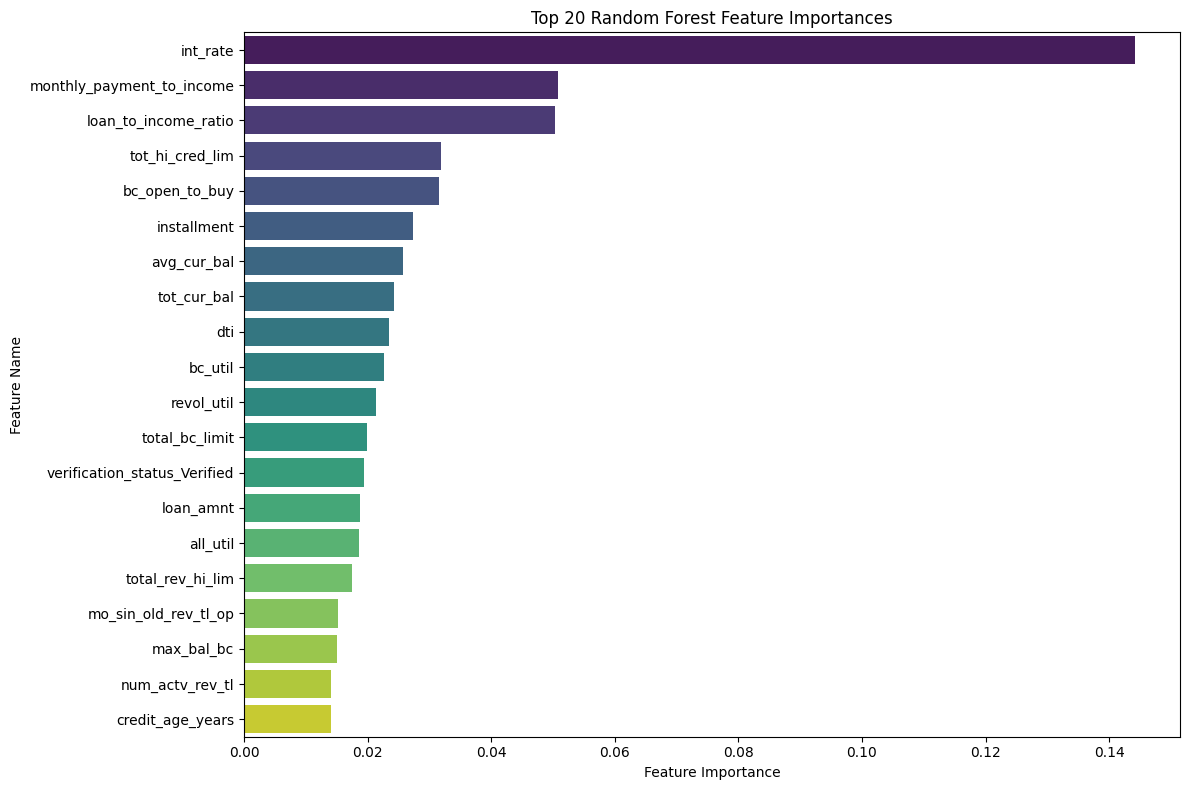

In [ ]:
# Plot the top 20 most important features
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_features.head(20).values, y=sorted_features.head(20).index, palette='viridis')
plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [ ]:
df['loan_status']

,loan_status
0,Fully Paid
1,Fully Paid
2,Fully Paid
3,Fully Paid
4,Fully Paid
...,...
79867,Charged Off
79868,Charged Off
79869,Fully Paid
79870,Fully Paid


In [ ]:
top_20_features = sorted_features.head(20).index.tolist()
x_top20=df[top_20_features]
y=df['loan_status']

x_top20_train, x_top20_test, y_train, y_test = train_test_split(x_top20, y, test_size=0.2, random_state=42)

print(f"Shape of X_top20: {x_top20.shape}")
print(f"Shape of X_top20_train: {x_top20_train.shape}")
print(f"Shape of X_top20_test: {x_top20_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_top20: (79872, 20)
Shape of X_top20_train: (63897, 20)
Shape of X_top20_test: (15975, 20)
Shape of y_train: (63897,)
Shape of y_test: (15975,)


In [ ]:
x_top20.columns

Index(['loan_status_numeric', 'int_rate', 'monthly_payment_to_income',
       'loan_to_income_ratio', 'bc_open_to_buy', 'tot_hi_cred_lim',
       'avg_cur_bal', 'installment', 'verification_status_Verified', 'bc_util',
       'dti', 'tot_cur_bal', 'home_ownership_MORTGAGE', 'total_bc_limit',
       'loan_amnt', 'total_rev_hi_lim', 'revol_util', 'all_util',
       'home_ownership_RENT', 'mort_acc'],
      dtype='object')

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Replace infinite values with NaN in both training and test sets
x_top20_train.replace([np.inf, -np.inf], np.nan, inplace=True)
x_top20_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Calculate means for all columns from the training set
imputation_means = x_top20_train.mean()

# Impute missing values (NaN, now including former inf) in both training and test sets
for col in x_top20_train.columns:
    # Explicitly re-assign the imputed column to avoid inplace issues on copies
    x_top20_train[col] = x_top20_train[col].fillna(imputation_means[col])
    x_top20_test[col] = x_top20_test[col].fillna(imputation_means[col])



# Create an instance of LabelEncoder
le = LabelEncoder()

# Fit and transform y_train
y_train_encoded = le.fit_transform(y_train)

# Transform y_test using the same fitted LabelEncoder
y_test_encoded = le.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_top20_train)
X_test_scaled = scaler.transform(x_top20_test)

# Initialize a LogisticRegression model
lr_model = LogisticRegression(class_weight='balanced',solver='liblinear', max_iter=1000, random_state=42)

# Train the LogisticRegression model
lr_model.fit(X_train_scaled, y_train_encoded )

print("Logistic Regression model trained successfully after handling NaN and infinite values.")

Logistic Regression model trained successfully after handling NaN and infinite values.


**Reasoning**:
The previous code block successfully trained the Logistic Regression model after handling NaN and infinite values, which resolves the original error and completes the subtask.



In [ ]:
print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# # Make predictions on the test dataset
y_pred=lr_model.predict(X_test_scaled)


# # Calculate evaluation metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)

# # Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.6536
Precision: 0.8843
Recall: 0.6564
F1-Score: 0.7535


In [ ]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions for the positive class (class 1)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_proba)

# Calculate AUC score
auc_score = auc(fpr, tpr)

print(f"AUC-ROC Score: {auc_score:.4f}")

AUC-ROC Score: 0.7005


In [ ]:
from xgboost import XGBClassifier

# Initialize the XGBClassifier model
# Using n_estimators=100 and max_depth=5 for a reasonable balance between performance and training time
# In a real scenario, these hyperparameters would be tuned.
# Calculate ratio of negative to positive class
negative = (y_train_encoded == 0).sum()
positive = (y_train_encoded == 1).sum()
scale = negative / positive  # usually around 4.0

model = XGBClassifier(scale_pos_weight=scale)
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, random_state=42, objective='binary:logistic', eval_metric='logloss')

# Train the XGBoost model
xgb_model.fit(x_top20_train, y_train_encoded)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Make predictions on the test dataset using the XGBoost model
y_pred_xgb = xgb_model.predict(x_top20_test)

# Get probability predictions for the positive class (class 1) for AUC-ROC
y_pred_proba_xgb = xgb_model.predict_proba(x_top20_test)[:, 1]

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb)
recall_xgb = recall_score(y_test_encoded, y_pred_xgb)
f1_xgb = f1_score(y_test_encoded, y_pred_xgb)

# Calculate ROC curve and AUC score
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test_encoded, y_pred_proba_xgb)
auc_score_xgb = auc(fpr_xgb, tpr_xgb)

# Print the evaluation metrics
print(f"XGBoost Model Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"AUC-ROC Score: {auc_score_xgb:.4f}")

XGBoost Model Performance:
Accuracy: 0.8061
Precision: 0.8181
Recall: 0.9767
F1-Score: 0.8904
AUC-ROC Score: 0.7191


In [ ]:
class_distribution = pd.Series(y_train_encoded).value_counts()
class_percentage = pd.Series(y_train_encoded).value_counts(normalize=True) * 100

print("Class Distribution (Counts):")
print(class_distribution)
print("\nClass Distribution (Percentages):")
print(class_percentage)

Class Distribution (Counts):
1    51487
0    12410
Name: count, dtype: int64

Class Distribution (Percentages):
1    80.578118
0    19.421882
Name: proportion, dtype: float64


# 5. Risk Tier Segmentation
Using predicted default probabilities, we segment borrowers into
Low / Medium / High risk tiers and validate using actual default rates.

**Reasoning**:
The first step is to predict the probabilities of default for the test set using the trained XGBoost model and store them in a new DataFrame along with the true labels.



In [ ]:
y_pred_proba_xgb=xgb_model.predict_proba(x_top20_test)[:,1]

risk_df=pd.DataFrame({

        "true_label":y_test_encoded,
        "predicted_proba":y_pred_proba_xgb

})

risk_df.head()









# y_pred_proba_xgb = xgb_model.predict_proba(x_top20_test)[:, 1]

# risk_df = pd.DataFrame({
#     'true_label': y_test_encoded,
#     'predicted_proba': y_pred_proba_xgb
# })

# print("DataFrame with true labels and predicted probabilities created:")
# display(risk_df.head())

,true_label,predicted_proba
0,0,0.752329
1,0,0.591716
2,1,0.847786
3,0,0.767400
4,1,0.800158


**Reasoning**:
Now that the predicted probabilities are in the `risk_df`, the next step is to categorize these probabilities into the defined risk tiers ('Low Risk', 'Medium Risk', 'High Risk') and add them as a new column to the DataFrame.



In [ ]:
risk_bins = [0, 0.3, 0.6, 1.0]
risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']
risk_df['risk_tier']=pd.cut(risk_df["predicted_proba"], bins=risk_bins, labels=risk_labels, right=True)

risk_df.head()




# risk_bins = [0, 0.3, 0.6, 1.0]
# risk_labels = ['Low Risk', 'Medium Risk', 'High Risk']
# risk_df['risk_tier'] = pd.cut(risk_df['predicted_proba'], bins=risk_bins, labels=risk_labels, right=True)

# print("Risk tiers assigned successfully:")
# display(risk_df.head())

,true_label,predicted_proba,risk_tier
0,0,0.752329,High Risk
1,0,0.591716,Medium Risk
2,1,0.847786,High Risk
3,0,0.767400,High Risk
4,1,0.800158,High Risk


**Reasoning**:
The next step is to calculate the actual default rate for each risk tier. This involves grouping the `risk_df` by the newly created 'risk_tier' column and then calculating the mean of the 'true_label' (which represents default status) for each tier.



In [ ]:
default_rates_per_tier=risk_df.groupby('risk_tier')['true_label'].mean().reset_index()
default_rates_per_tier.rename(columns={'true_label':'actual_default_rate'}, inplace=True)


default_rates_per_tier

# default_rates_per_tier = risk_df.groupby('risk_tier')['true_label'].mean().reset_index()
# default_rates_per_tier.rename(columns={'true_label': 'actual_default_rate'}, inplace=True)

# print("Actual default rates per risk tier:")
# display(default_rates_per_tier)

/tmp/ipython-input-232/1346476182.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rates_per_tier=risk_df.groupby('risk_tier')['true_label'].mean().reset_index()


,risk_tier,actual_default_rate
0,Low Risk,0.466667
1,Medium Risk,0.558663
2,High Risk,0.832999


**Reasoning**:
The previous code block produced a FutureWarning regarding the `groupby` method. To explicitly control the behavior and suppress the warning, I will add `observed=False` to the `groupby` call, ensuring that all risk tiers are included in the output even if some are empty.



**Reasoning**:
Now that the actual default rates per risk tier have been calculated, the next step is to visualize these rates using a bar chart to provide a clear and intuitive summary of the risk segmentation.



/tmp/ipython-input-232/2683185502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk_tier', y='actual_default_rate', data=default_rates_per_tier, palette='viridis')


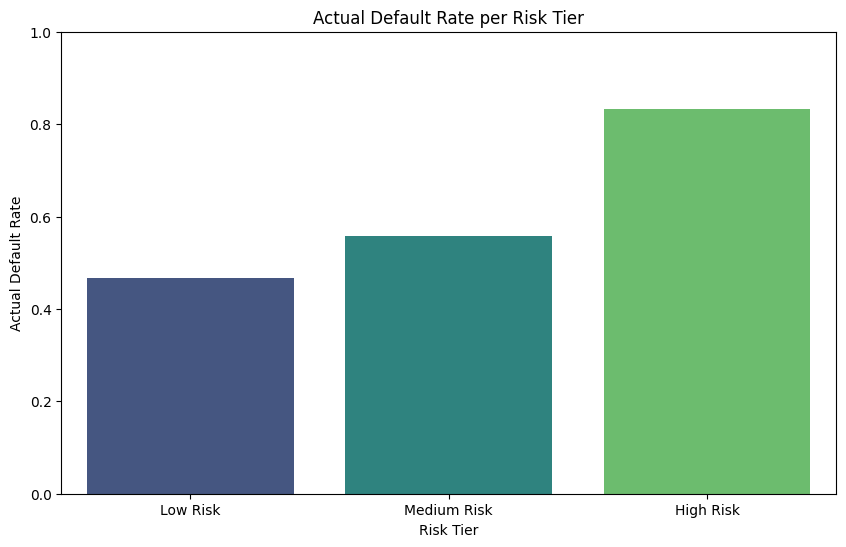

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='risk_tier', y='actual_default_rate', data=default_rates_per_tier, palette='viridis')
plt.title('Actual Default Rate per Risk Tier')
plt.xlabel('Risk Tier')
plt.ylabel('Actual Default Rate')
plt.ylim(0, 1) # Ensure y-axis is between 0 and 1 for rates
plt.show()
